In [ ]:
Content
1. Claude.md Guide
2. Context Engineering
3. Sub-Agent Architectures
4. Prompt Patterns (Best practices)
5. Hooks
6. Agent Team

In [ ]:
Source:
1. https://www.aibuilderclub.com/blog/claude-code

# 1. Claude.md Guide

In [ ]:
# CLAUDE.md

## 1. Project Overview
What this project is about.

## 2. Stack & Key Dependencies
The tech you use and versions that matter.

## 3. Conventions
How code should be written in this project.

## 4. Important Files
Files that Claude Code should reference or be careful with.

## 5. Commands
npm or other project commands
    
## 6. Don'ts and Constraints
Things Claude Code should never do without asking.

# 2. Context Engineering

In [ ]:
- Prompt engineering asks: How do I write better instructions? 
- Context engineering asks: What is the complete state of the model context window at each step of this task, and how do I make it as useful as possible?


Context Engineering Idea:
    - find the smallest set of high-signal tokens that maximizes the likelihood of your desired outcome.
    - Every noisy or redundant token you remove is a direct performance improvement, and reduce cost.
        
# Four Components of Context to Manage
1. System prompt -- Your instructions, agent role, behavioral guidelines
    a. Two failure Modes:
        - Too specific: Hardcoded if-then logic for every edge case. Hard to maintain, and does not generalize. The prompt becomes a 3,000-token specification that the model follows rigidly until it encounters something you didn't specify.
        - Too vague: High-level guidance that assumes shared context the model doesn't have. "Be helpful and accurate." The model interprets this differently on every run.
    b. Instead, in your prompts, specific enough to guide behavior and flexible enough to let the model use judgment
            
    c. Correct way to format prompt:
        - using XML tags like <background_information>, <instructions>, and <output_description>. Separate what the agent is for, what it should do from how it should format output.
            
2. Tools -- Function definitions the agent can call, plus their results
    a. Tools add context cost: the function definition (always in context) and the tool result (added each time the tool is called).
    b. Failure Modes:
        - The most common tool design mistake is giving agents too many tools with overlapping functionality
    c. So, tools should always be a minimal viable set.
    d. Designing Tools
        - One clear purpose per tool
        - No overlap in what tools cover
        - Descriptive parameter names that guide correct usage
        - Errors that are informative rather than cryptic
        - Results that are token-efficient -- return structured summaries, with only required data, not raw dumps
        
        
3. Message history -- The conversation so far, including all prior tool calls and outputs
    a. Multi-session tasks lose continuity when their context resets between sessions.
    b. Maintaining a persistent file (NOTES.md, TODO.md) that survives across context resets.
    c. Code code agent maintains a to-do list and writes notes about decisions it has made, blockers it has found, and the current state of work in progress

            
4. Retrieved data -- Documents, database results, file contents loaded into context

Problems with Context Window:
- Context rot is observed where LLM ability to accurately recall information decreases as the context window fills. 
                                                                                                                                      

# 3. Sub-Agent Architectures

In [ ]:
- The pattern: a coordinating agent maintains a high-level plan. It delegates focused sub-tasks to specialized sub-agents, each of which starts with a clean context window. The sub-agent explores its task deeply -- potentially using tens of thousands of tokens in tool calls and reasoning -- then returns a condensed summary (typically 1,000-2,000 tokens) to the coordinator.
- The coordinator never sees the sub-agent working context. It receives only the distilled output. This isolation means the main agent context stays manageable regardless of how deeply the sub-agents explore.
- Benefits: parallel exploration, isolated context windows, and the ability to have sub-agents with specialized system prompts suited to their specific task.
- Best Practices:
    1. Compaction: It maintains the flow of a single agent across long interactions. Use it when the task has natural checkpoints where history can be safely summarized.
    2. Structured note-taking: Use it when the agent needs to remember decisions across resets. when you need an audit trail of what the agent tried and why.
    3. Just-in-time retrieval: Never pre-load -- always retrieve on demand. Use it whenever the agent information needs are unknowable upfront.
    4. Sub-agent architectures handle complex research and analysis where parallel exploration pays off. Use them when a single agent context budget can not accommodate the necessary depth of exploration, or when parallel subtasks would benefit from simultaneous execution.



In [ ]:
A sub-agent is a separate Claude Code session spawned by the parent via the Task tool. The parent passes a focused prompt and (optionally) a list of files; the sub-agent runs in its own fresh context window, does the work, and returns a single string result.

Three properties matter:
    1. Isolated context — the parent's context isn't polluted by the sub-agent's exploration.
    2. Parallel execution — multiple sub-agents run concurrently, bounded by Anthropic API rate limits.
    3. Single return value — the parent only sees the sub-agents final answer, not its trajectory.

# When to Use Sub-Agents
1. Parallel Exploration:        
2. Specialized Personas: Each sub-agent may have a specialized persona.

Example Prompt: Use the Task tool to spawn 4 sub-agents in parallel. Each one should read a different layer of this codebase (auth, api, db, tests) and return a 150-word summary of the patterns it sees.

# When not to use sub-agents
1. Sequential work or Trivial tasks.

Prompts for Multi-Agents
    - Research Agents: Spawn 3 sub-agents. Each one researches a different approach to [problem]: (a) library-based, (b) custom code, (c) external service. Each returns a 200-word comparison of pros, cons, and rough cost/complexity. Synthesize into a recommendation.
    - Codebase Explorer: Spawn N sub-agents, one per directory in this list: [...]. Each sub-agent reads its directory, identifies the 3 most important files, and returns a 100-word summary covering: purpose, key patterns, dependencies. Aggregate into a 500-word architecture brief.

Common mistakes with Sub-Agents:
1. Spawning sub-agents for serial work
2. Not aggregating result, or dump their complete outputs into the main agent.


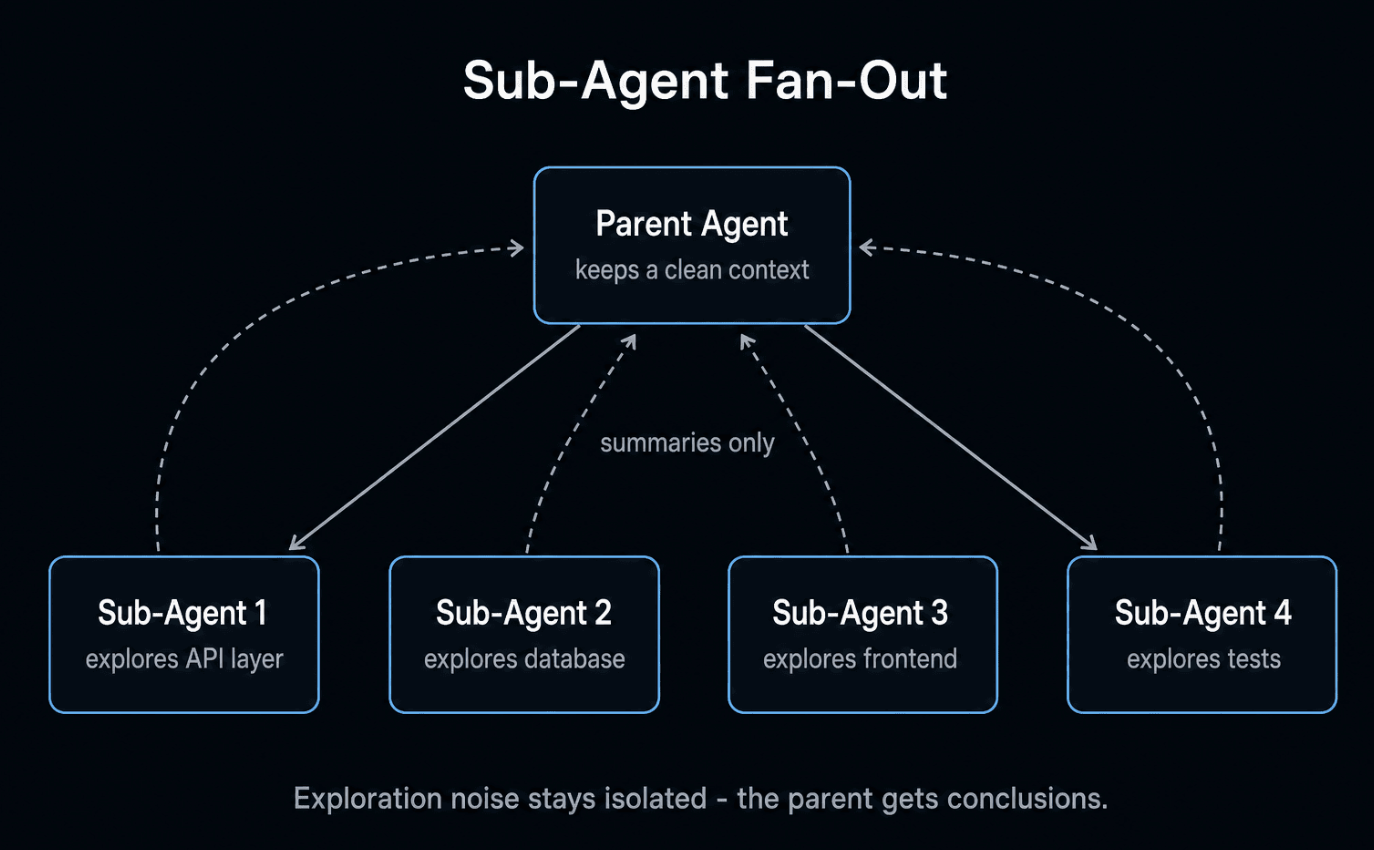

# 4. Prompt Patterns (Best practices)

In [ ]:
Idea: treat Claude Code like a talented new hire on day one. When you give context, constraints, and verification steps, you are onboarding that new hire. The better the onboarding, the better the output.
    
1. Reference existing patterns explicitly
    Why it works: Claude Code reads your whole repo, but it does not know which files represent your preferred patterns. When you point to a specific file, it matches the style exactly — imports, error handling, response shape, everything.
    Bad: "Add a new API route for user preferences."
    Good: Add a new API route for user preferences. Follow the exact patterns in app/api/stripe/checkout/route.ts — same error handling, same response format, same auth check.

2. Describe the outcome, not the steps
    Why it works: Why it works: When you dictate steps, you are limiting Claude Code to your plan. When you describe outcomes, it chooses the best implementation using the patterns already in your codebase. It often finds better approaches than you would have prescribed.
    Bad: Create a file called UserPrefs.tsx. Import useState. Add a form with three fields...
    Good: Users need to set their email notification preferences — daily digest, weekly summary, or none. When they save, it should update via our existing API pattern and show a success toast.

3. The constraint sandwich
    Structure: desired outcome + constraints + quality bar.
    Why it works: Constraints prevent scope creep. The quality bar prevents lazy outputs. Without constraints, Claude Code might refactor your entire theme system when all you wanted was one page.

    Bad: Add dark mode support to the settings page.
    Good: Add dark mode support to the settings page. Constraints: use our existing ThemeProvider (do not create a new one), keep the same Tailwind classes we use elsewhere, don't touch any component outside app/settings/. The result should look intentional — not like someone just inverted the colors.

4. Ask it to read before it writes
    Why it works: Claude Code will read files if relevant, but sometimes it rushes to write. Explicitly asking it to read first ensures it discovers existing utilities instead of reinventing them. This dramatically reduces duplicate code.
    Bad: Add a reusable confirmation dialog component.
    Good: Before making any changes, read through the entire app/components/ui/ directory and app/lib/utils.ts. Understand what utilities and components already exist. Then add a reusable confirmation dialog that follows the same patterns.

5. The "fix it like a senior engineer" frame
    Why it works: Without this frame, Claude Code often fixes, failing tests by making the tests match the broken code. The senior engineer frame sets the right priority: tests define correctness, code should match.
    Bad: Fix the failing tests.
    Good: Run the test suite. For every failing test, fix the underlying code — don't modify the tests. If a test is genuinely wrong, explain why before changing it.

6. Incremental scope with checkpoints
   Why it works: Large scope = large risk of going off track. By checkpointing, you review after each piece. If step 1 goes sideways, you lost 5 minutes
    Bad: Build a complete user dashboard with analytics, settings, billing, and team management.                             
    Good: Let's build the user dashboard in steps. Start with just the analytics tab — show a chart of daily active usage from our existing /api/analytics endpoint. Commit when it works. I'll review before we move to the next tab.

7. Give it the "why"
    Why it works: The "why" gives Claude Code decision-making context. It knows this is about scrapers (not general rate limiting), it knows the deployment target (Vercel edge), and it knows the infrastructure constraint (no Redis). Every decision it makes will be better.
    Bad: Add rate limiting to the API.
    Good: We are getting hit by scrapers on /api/public/courses — 10K requests/min from single IPs. Add rate limiting to all /api/public/ routes. We are on Vercel, so it needs to work with edge functions. We do not want to add Redis for this — use in-memory or Vercel's built-in if available.

8. The migration pattern
    Why it works: Migrations have a clear before/after. By giving Claude Code the source file, the target pattern, and a verification step (run tests), you get a reliable migration with built-in validation.
    Bad: Migrate our auth to the app router.
    Good: We are migrating from pages/ router to app/ router in Next.js. Take pages/api/auth/[...nextauth].ts and rewrite it as an app/api/auth/[...nextauth]/route.ts. Keep the exact same behavior and auth providers. Run the existing auth tests after migration to verify nothing broke.

9. Debug with context, not just symptoms
    Why it works: Debugging requires context. The more you narrow the problem — what changed, what the symptoms are, where you have already looked — the faster Claude Code converges on the fix. "It is broken triggers a shotgun approach.
    Bad: The login page is broken.
    Good: After deploying commit abc123, users clicking Sign In get a blank page. No errors in the browser console. The Supabase auth callback at /auth/callback returns 200 but the redirect does not fire. Check if the auth callback route is handling the code exchange correctly and if the redirect URL matches our NEXT_PUBLIC_SITE_URL.

10. The refactor with safety net
    Why it works: Refactors are scary because they can break things silently. By specifying the safety net (same public API, run build + tests), you get the refactor and the confidence it didn't break anything.
    Good: Clean up lib/resend.ts — it's getting messy.
    Bad: Refactor lib/resend.ts to split the email templates into separate files under lib/emails/. Keep the same public API — every function that iss currently exported should still be importable from lib/resend.ts (re-export from the new files). Run the build and tests after to make sure nothing breaks.

# 5. Hooks

In [ ]:
- A hook is an external command that runs automatically at a specific moment in the agent lifecycle. File about to be written? Your hook fires first. Command finished? Your hook post-processes the result.
- Make formatting, security, and quality gates fire 100% of the time.
- Hooks are deterministic (executed always). Instructions in CLAUDE.md are suggestions the model usually follows.
- Type /hooks inside Claude Code to see everything currently registered

# Events:
Event	When it fires	What it's for
1. PreToolUse	
    - When it fires: Before any tool call executes	
    - Usecase: The only event that can block an action

2. PostToolUse	
    - When it fires: After a tool call completes	
    - Usecase: Post-processing: format, lint, test

3. Stop	
    - When it fires: When Claude is about to finish responding	
    - Usecase: Quality gates: do not let it stop with failing tests

4. Notification
    - When it fires: When Claude needs your attention
    - Usecase: Forward to desktop/Slack so you can context-switch

5. SessionStart
    - When it fires: New session begins	
    - Usecase: Inject env vars, check dependencies, start logging

6. UserPromptSubmit
    - When it fires: You send a message	
    - Usecase: Attach extra context before the model sees it    

There are more hooks: SubagentStart/SubagentStop, PreCompact, WorktreeCreate/WorktreeRemove




# Handlers
1. Command:	A shell command or script. Receives event JSON via stdin, returns decision via stdout.	90% of hooks. Fast, deterministic, free.
2. HTTP:	A request to a URL	Push events to audit systems or internal APIs
3. Prompt:	A Claude model evaluates the event	Grey areas a regex can not judge ("is this code security-sensitive?"). Costs tokens.
4. Agent:	A full agent instance investigates	Heavyweight checks needing multi-step reasoning. Rare.


# Configuration Lives at
1. ~/.claude/settings.json:	All your projects	Security rules, audit logs, notifications
2. .claude/settings.json:	This project, committed to git	Team-shared rules: this repo formats with Prettier
3. .claude/settings.local.json:	This project, gitignored	Personal preferences, machine-specific paths    


In [ ]:
# The Three Things a Hook Can Do
1. Allow - do nothing, let the pipeline continue. Pure logging hooks live here.
2. Block - stop the action. Only available in PreToolUse. Claude receives an error explaining the action was rejected by an external rule.
3. Inject - add information into the conversation. Example: your linter found 3 warnings after a file write, inject them so Claude sees and fixes them.

# Hooks Example 
1. Auto-format after every edit
2. Block force-push to main
3. Protect secret files: PreToolUse, matcher Write|Edit. Block writes to .env, credentials.json
4. Quality gate on Stop: Stop event. Run your linter and test on claude finish. Errors found? Inject them back: ESLint reports.
5. Desktop notification when input needed
6. Full audit log: PreToolUse or PostToolUse, no matcher. Append tool name, input, and timestamp to a JSONL file. 
7. Supabase migration guard: PreToolUse, matcher Bash. If the command contains supabase db reset

# Pratical Rules
1. Keep hooks dumb. Check a path, match a regex, read an exit code.
2. Watch latency. A 3-second hook on PreToolUse means every tool call waits 3 seconds. Claude Code makes dozens of tool calls per task.
3. Test the blocker hooks. A formatting hook that silently fails costs you nothing. A force-push blocker that silently fails costs you a main branch. 

    